In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Setup path
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "alpha_lab").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from alpha_lab.config import get_paths
paths = get_paths()
print(f"Project root: {ROOT}")

Project root: /home/linnnw/projects/alpha-lab


In [3]:
# Load data
from alpha_lab.data.loader import load_prices
from alpha_lab.factors.momentum import momentum
from alpha_lab.factors.transform import zscore
from alpha_lab.portfolio.rebalance import generate_rebalance_schedule

# Load prices from CSV
csv_path = paths.data_raw_dir / "close.csv"
prices_df = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
prices_df.index.name = "date"
tickers = prices_df.columns.tolist()

print(f"Loaded {len(tickers)} tickers, {len(prices_df)} days")
print(f"Date range: {prices_df.index.min().date()} to {prices_df.index.max().date()}")
print(f"Tickers: {tickers}")

Loaded 222 tickers, 3457 days
Date range: 2009-09-29 to 2025-12-16
Tickers: ['PLPC', 'REGN', 'SEVN', 'NOVT', 'LPTH', 'GAIA', 'FRD', 'DVAX', 'WLFC', 'CSQ', 'TACT', 'GIII', 'WINA', 'HALO', 'HCKT', 'RMTI', 'MLAB', 'COO', 'IART', 'ADI', 'BCRX', 'CBSH', 'VSAT', 'CME', 'MIND', 'CASY', 'CNOB', 'OMAB', 'UBFO', 'CENTA', 'SPNS', 'CERS', 'ATRC', 'JKHY', 'CSCO', 'OSBC', 'VHC', 'TRI', 'ROST', 'CPSS', 'HIHO', 'INCY', 'MZTI', 'APYX', 'EYPT', 'FARM', 'HAS', 'SPOK', 'MFIC', 'CEVA', 'CTSO', 'OFIX', 'BKNG', 'LTRX', 'BCIC', 'WAFD', 'FRST', 'FBNC', 'IBIO', 'APEI', 'JACK', 'MVIS', 'SBLX', 'CCEC', 'MGEE', 'CALM', 'DOX', 'ACLS', 'SMTC', 'MASI', 'RYAAY', 'ACNB', 'IDCC', 'PRSO', 'URBN', 'MNDO', 'NAII', 'JAKK', 'PPC', 'ASRV', 'KLAC', 'MITK', 'LDWY', 'CROX', 'ASTC', 'BLKB', 'GIGM', 'SBUX', 'HWC', 'ZD', 'TBHC', 'SVC', 'PLAB', 'STRT', 'CLDX', 'DCOM', 'ULTA', 'TCBK', 'SGLY', 'MMSI', 'HTLD', 'CCRN', 'CNXN', 'TZOO', 'MSFT', 'IAC', 'CMCO', 'ULBI', 'NBTB', 'RGS', 'FAST', 'WTBA', 'QCOM', 'AIOT', 'QCRH', 'WERN', 'CWST', '

In [4]:
# Compute factor (momentum) and forward returns
lookback = 20  # momentum lookback
lag = 1        # avoid lookahead bias
holding_period = 21  # ~1 month forward return

# Momentum factor
factor = momentum(prices_df, lookback=lookback, lag=lag)
factor_z = zscore(factor, axis=1)  # cross-sectional z-score

# Forward returns
fwd_returns = prices_df.pct_change(holding_period).shift(-holding_period)

print(f"Factor shape: {factor_z.shape}")
print(f"Forward returns shape: {fwd_returns.shape}")

Factor shape: (3457, 222)
Forward returns shape: (3457, 222)


## 1. Information Coefficient (IC)

IC measures the Spearman rank correlation between factor values and subsequent returns.
- IC > 0 means factor predicts returns positively
- |IC| > 0.05 is typically considered meaningful

In [5]:
def compute_ic_series(factor: pd.DataFrame, fwd_returns: pd.DataFrame) -> pd.Series:
    """
    Compute Spearman IC for each date.
    
    Args:
        factor: DataFrame (date x asset) of factor values
        fwd_returns: DataFrame (date x asset) of forward returns
    
    Returns:
        Series of IC values indexed by date
    """
    common_dates = factor.index.intersection(fwd_returns.index)
    ic_values = []
    
    for date in common_dates:
        f = factor.loc[date].dropna()
        r = fwd_returns.loc[date].dropna()
        common = f.index.intersection(r.index)
        
        if len(common) >= 3:
            ic, _ = stats.spearmanr(f[common], r[common])
            ic_values.append({"date": date, "ic": ic})
    
    return pd.DataFrame(ic_values).set_index("date")["ic"]

ic_series = compute_ic_series(factor_z, fwd_returns)
print(f"IC computed for {len(ic_series)} dates")

/tmp/ipykernel_8848/2284057230.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = stats.spearmanr(f[common], r[common])


IC computed for 3436 dates


In [6]:
# IC statistics
ic_mean = ic_series.mean()
ic_std = ic_series.std()
ic_ir = ic_mean / ic_std if ic_std > 1e-6 else 0  # Information Ratio
ic_hit_rate = (ic_series > 0).mean()

print("=" * 40)
print("IC Statistics")
print("=" * 40)
print(f"Mean IC:      {ic_mean:.4f}")
print(f"Std IC:       {ic_std:.4f}")
print(f"IC IR:        {ic_ir:.4f}")
print(f"IC Hit Rate:  {ic_hit_rate:.1%}")
print("=" * 40)

IC Statistics
Mean IC:      -0.0204
Std IC:       0.1170
IC IR:        -0.1741
IC Hit Rate:  45.1%


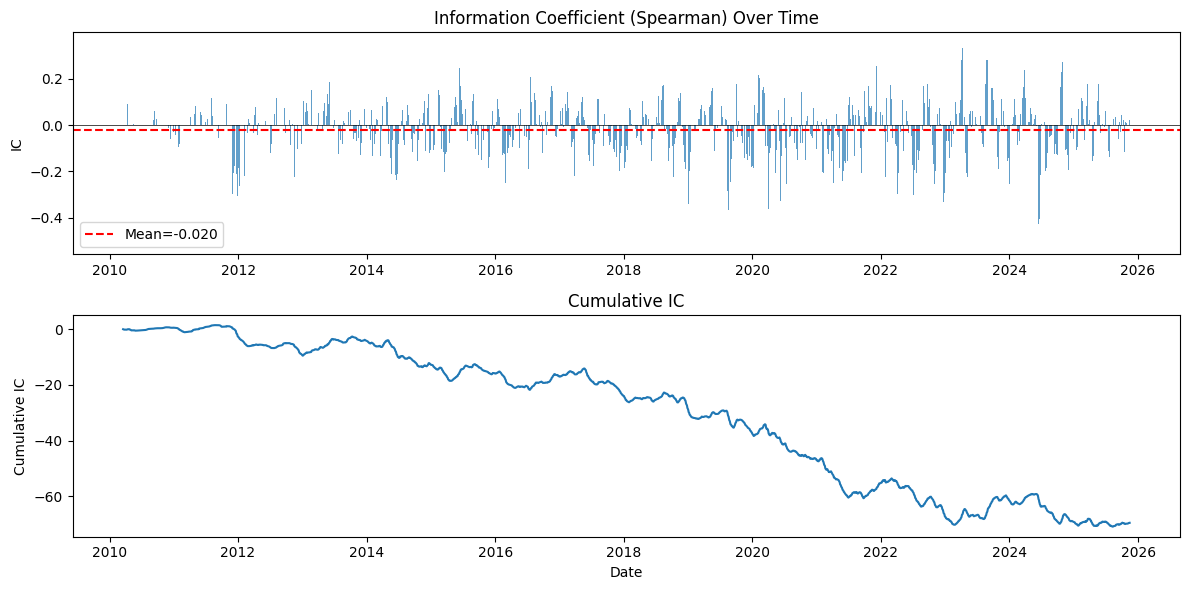

In [7]:
# Plot IC time series
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# IC over time
ax1 = axes[0]
ax1.bar(ic_series.index, ic_series.values, width=1, alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.axhline(y=ic_mean, color='red', linestyle='--', label=f'Mean={ic_mean:.3f}')
ax1.set_title('Information Coefficient (Spearman) Over Time')
ax1.set_ylabel('IC')
ax1.legend()

# Cumulative IC
ax2 = axes[1]
ax2.plot(ic_series.cumsum(), linewidth=1.5)
ax2.set_title('Cumulative IC')
ax2.set_ylabel('Cumulative IC')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## 2. Quantile Returns (Top-Bottom Spread)

Group assets by factor quintiles and compare returns of top vs bottom groups.

In [8]:
def compute_quantile_returns(
    factor: pd.DataFrame,
    fwd_returns: pd.DataFrame,
    n_quantiles: int = 5,
) -> pd.DataFrame:
    """
    Compute average forward returns for each factor quantile.
    
    Args:
        factor: DataFrame (date x asset)
        fwd_returns: DataFrame (date x asset)
        n_quantiles: number of quantile groups
    
    Returns:
        DataFrame with quantile returns over time
    """
    common_dates = factor.index.intersection(fwd_returns.index)
    quantile_returns = []
    
    for date in common_dates:
        f = factor.loc[date].dropna()
        r = fwd_returns.loc[date].dropna()
        common = f.index.intersection(r.index)
        
        if len(common) >= n_quantiles:
            # Assign quantiles (1=lowest factor, n=highest factor)
            try:
                quantiles = pd.qcut(f[common], q=n_quantiles, labels=False, duplicates='drop') + 1
            except ValueError:
                continue
            
            row = {"date": date}
            for q in range(1, n_quantiles + 1):
                mask = quantiles == q
                if mask.sum() > 0:
                    row[f"Q{q}"] = r[common][mask].mean()
            quantile_returns.append(row)
    
    return pd.DataFrame(quantile_returns).set_index("date")

quantile_rets = compute_quantile_returns(factor_z, fwd_returns, n_quantiles=5)
print(f"Quantile returns computed for {len(quantile_rets)} dates")

Quantile returns computed for 3436 dates


In [9]:
# Quantile statistics
print("=" * 50)
print("Average Returns by Factor Quantile")
print("=" * 50)
print(quantile_rets.mean().to_string())
print()

# Top-Bottom spread
if "Q5" in quantile_rets.columns and "Q1" in quantile_rets.columns:
    spread = quantile_rets["Q5"] - quantile_rets["Q1"]
    print(f"Top-Bottom Spread (Q5-Q1):")
    print(f"  Mean:   {spread.mean():.4f}")
    print(f"  Std:    {spread.std():.4f}")
    print(f"  t-stat: {spread.mean() / (spread.std() / np.sqrt(len(spread))):.2f}")
print("=" * 50)

Average Returns by Factor Quantile
Q1    0.017989
Q2    0.015546
Q3    0.013917
Q4    0.012186
Q5    0.010446

Top-Bottom Spread (Q5-Q1):
  Mean:   -0.0075
  Std:    0.0528
  t-stat: -8.37


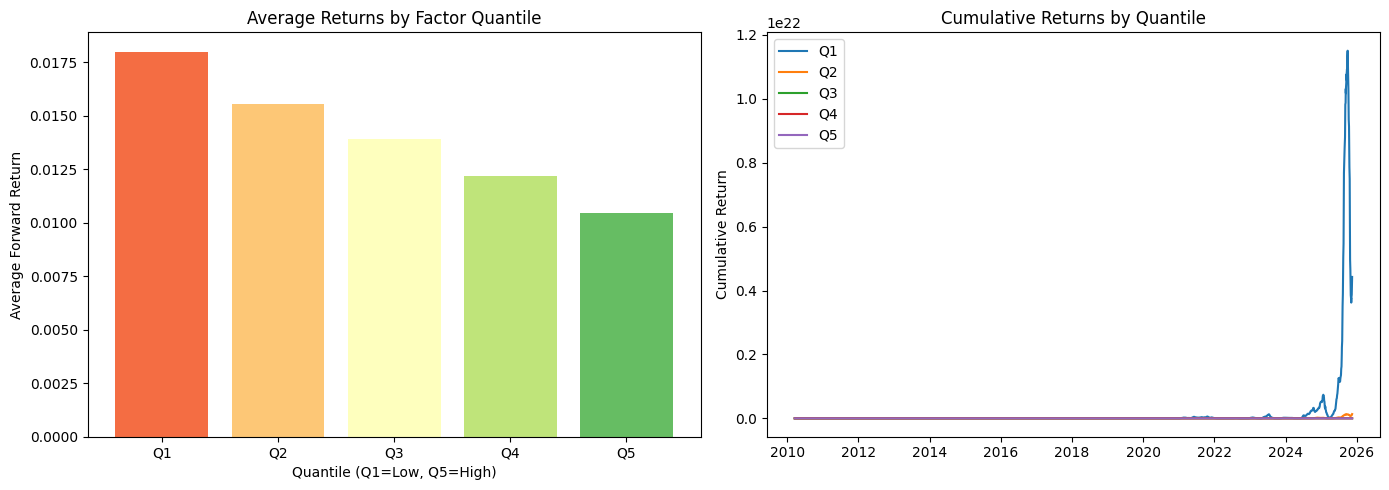

In [10]:
# Plot quantile cumulative returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average returns
ax1 = axes[0]
mean_rets = quantile_rets.mean()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(mean_rets)))
ax1.bar(mean_rets.index, mean_rets.values, color=colors)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_title('Average Returns by Factor Quantile')
ax1.set_xlabel('Quantile (Q1=Low, Q5=High)')
ax1.set_ylabel('Average Forward Return')

# Cumulative returns
ax2 = axes[1]
cum_rets = (1 + quantile_rets).cumprod()
for col in cum_rets.columns:
    ax2.plot(cum_rets.index, cum_rets[col], label=col, linewidth=1.5)
ax2.set_title('Cumulative Returns by Quantile')
ax2.set_ylabel('Cumulative Return')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Factor Turnover

Measure how much the factor-based weights change between periods.

In [11]:
from alpha_lab.portfolio.weighting import top_k_long_only

# Generate weights from factor
rebalance_dates = generate_rebalance_schedule(
    trading_calendar=prices_df.index,
    start_date=prices_df.index.min(),
    end_date=prices_df.index.max(),
    freq="M",
)

factor_reb = factor_z.reindex(rebalance_dates).dropna(how='all')
weights = top_k_long_only(factor_reb, k_pct=0.2, equal_weight=True)

print(f"Rebalance dates: {len(rebalance_dates)}")
print(f"Weight dates: {len(weights)}")

2026-01-12 15:43:48 | INFO     | alpha_lab.portfolio.rebalance | Generated 196 rebalance dates (freq=M)
Rebalance dates: 196
Weight dates: 196


In [12]:
def compute_turnover(weights: pd.DataFrame) -> pd.Series:
    """
    Compute turnover as sum of absolute weight changes.
    
    Turnover = sum(|w_t - w_{t-1}|) / 2
    Range: 0 (no change) to 1 (complete portfolio flip)
    """
    weight_changes = weights.diff().abs()
    turnover = weight_changes.sum(axis=1) / 2  # divide by 2 to get one-way turnover
    return turnover.iloc[1:]  # skip first period (no prior weights)

turnover = compute_turnover(weights)
print(f"Turnover computed for {len(turnover)} periods")

Turnover computed for 195 periods


In [13]:
# Turnover statistics
print("=" * 40)
print("Turnover Statistics")
print("=" * 40)
print(f"Mean Turnover:   {turnover.mean():.1%}")
print(f"Median Turnover: {turnover.median():.1%}")
print(f"Max Turnover:    {turnover.max():.1%}")
print(f"Min Turnover:    {turnover.min():.1%}")
print("=" * 40)

Turnover Statistics
Mean Turnover:   70.5%
Median Turnover: 75.0%
Max Turnover:    97.7%
Min Turnover:    0.0%


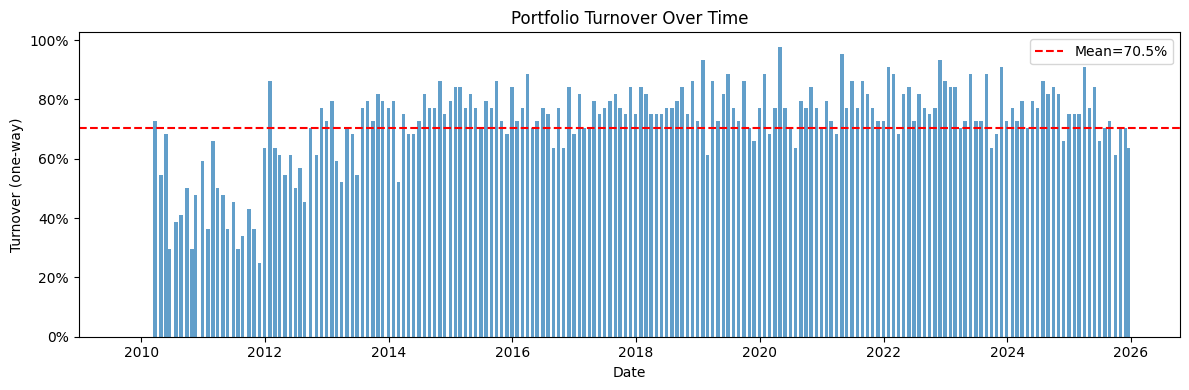

In [14]:
# Plot turnover
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(turnover.index, turnover.values, width=20, alpha=0.7)
ax.axhline(y=turnover.mean(), color='red', linestyle='--', label=f'Mean={turnover.mean():.1%}')
ax.set_title('Portfolio Turnover Over Time')
ax.set_ylabel('Turnover (one-way)')
ax.set_xlabel('Date')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

## Summary

Key factor quality metrics:

In [15]:
# Summary table
summary = {
    "IC Mean": f"{ic_mean:.4f}",
    "IC Std": f"{ic_std:.4f}",
    "IC IR (IC/Std)": f"{ic_ir:.4f}",
    "IC Hit Rate": f"{ic_hit_rate:.1%}",
    "Avg Turnover (monthly)": f"{turnover.mean():.1%}",
    "Ann. Turnover (est.)": f"{turnover.mean() * 12:.1%}",
}

if "Q5" in quantile_rets.columns and "Q1" in quantile_rets.columns:
    spread = quantile_rets["Q5"] - quantile_rets["Q1"]
    summary["Top-Bottom Spread"] = f"{spread.mean():.4f}"

print("\n" + "=" * 50)
print("FACTOR DIAGNOSTICS SUMMARY")
print("=" * 50)
for k, v in summary.items():
    print(f"{k:25s}: {v}")
print("=" * 50)


FACTOR DIAGNOSTICS SUMMARY
IC Mean                  : -0.0204
IC Std                   : 0.1170
IC IR (IC/Std)           : -0.1741
IC Hit Rate              : 45.1%
Avg Turnover (monthly)   : 70.5%
Ann. Turnover (est.)     : 845.9%
Top-Bottom Spread        : -0.0075
